# VGG Training Strategy: Progressive Dataset Revelation

## CIFAR-10 Dataset
- 60,000 images (32×32 RGB)
- 50,000 training | 10,000 testing

## Strategy
We progressively increase training data:

- Stage 1 → 10%
- Stage 2 → 25%
- Stage 3 → 50%
- Stage 4 → 75%
- Stage 5 → 100%

Each stage trains for 5 epochs → Total 25 epochs

## Importing Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

tf.__version__

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

## Loading Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## Data Preprocessing & Augmentation

In [3]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow(x_test, y_test, batch_size=64)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

## Progressive Schedule

In [4]:
progressive_fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
epochs_per_stage = 5

## Building VGG-style CNN

In [5]:
cnn = models.Sequential()

cnn.add(layers.Input(shape=(32,32,3)))

# Block 1
cnn.add(layers.Conv2D(64,3,padding='same',activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.Conv2D(64,3,padding='same',activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPooling2D(2))

# Block 2
cnn.add(layers.Conv2D(128,3,padding='same',activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.Conv2D(128,3,padding='same',activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPooling2D(2))

# Block 3
cnn.add(layers.Conv2D(256,3,padding='same',activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.Conv2D(256,3,padding='same',activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPooling2D(2))

# Dense
cnn.add(layers.Flatten())
cnn.add(layers.Dense(512,activation='relu'))
cnn.add(layers.Dropout(0.5))
cnn.add(layers.Dense(10,activation='softmax'))

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,251,786 (12.40 MB)

 Trainable params: 3,249,994 (12.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Compiling the Model

In [6]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Progressive Training

In [7]:
np.random.seed(42)
indices = np.random.permutation(len(x_train))

x_train = x_train[indices]
y_train = y_train[indices]

full_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
stage_boundaries = []

for stage_idx, frac in enumerate(progressive_fractions):

    n_samples = int(len(x_train) * frac)

    x_subset = x_train[:n_samples]
    y_subset = y_train[:n_samples]

    training_set = train_datagen.flow(x_subset, y_subset, batch_size=64)

    print("\n" + "="*60)
    print(f"STAGE {stage_idx+1}: {frac*100:.0f}% data ({n_samples:,} samples)")
    print("="*60)

    stage_boundaries.append(len(full_history['accuracy']))

    history = cnn.fit(
        training_set,
        validation_data=test_set,
        epochs=epochs_per_stage
    )

    for key in full_history:
        full_history[key].extend(history.history[key])

    print(f"\nStage {stage_idx+1} Complete:")
    print(f"Train Acc: {history.history['accuracy'][-1]:.4f}")
    print(f"Val Acc:   {history.history['val_accuracy'][-1]:.4f}")


STAGE 1: 10% data (5,000 samples)
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.2526 - loss: 2.6710 - val_accuracy: 0.1007 - val_loss: 2.7778
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.3222 - loss: 1.8596 - val_accuracy: 0.1513 - val_loss: 3.4445
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.3564 - loss: 1.7522 - val_accuracy: 0.1190 - val_loss: 3.9496
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.3746 - loss: 1.7095 - val_accuracy: 0.2011 - val_loss: 2.9032
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.3994 - loss: 1.6409 - val_accuracy: 0.2232 - val_loss: 2.3309

Stage 1 Complete:
Train Acc: 0.3994
Val Acc:   0.2232

STAGE 2: 25% data (12,500 samples)
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.4304 - loss: 1.5759 - val_accuracy: 0.4946 - val_loss: 1.3470
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.4699 - loss: 1.4749 - val_accuracy: 0.4179 - v

## Results Visualization

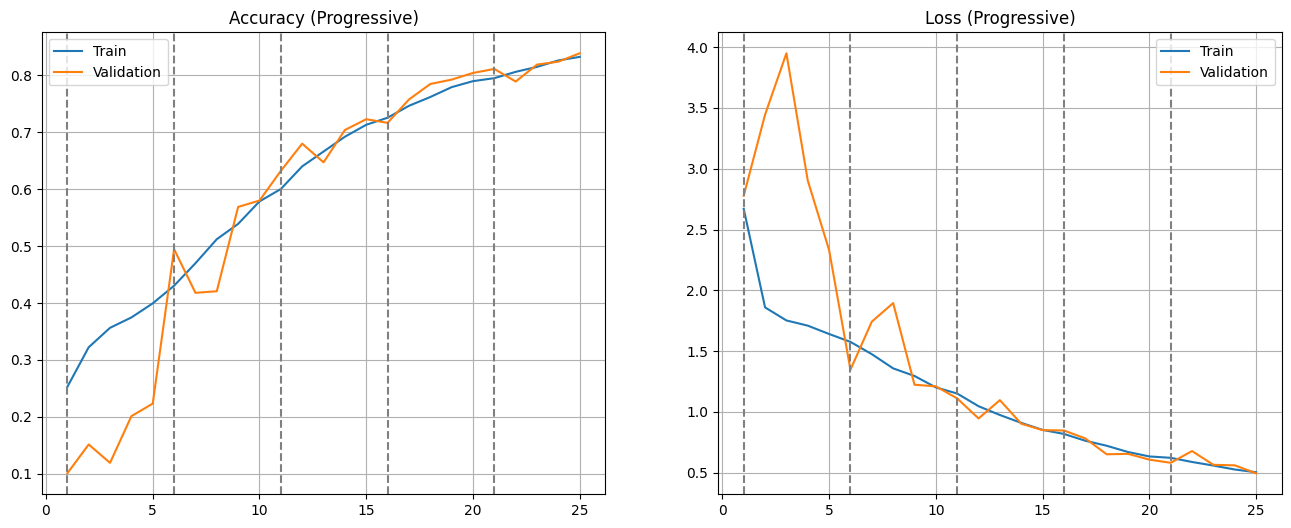

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

epochs_range = range(1, len(full_history['accuracy'])+1)

# Accuracy
ax1.plot(epochs_range, full_history['accuracy'], label='Train')
ax1.plot(epochs_range, full_history['val_accuracy'], label='Validation')

for i, b in enumerate(stage_boundaries):
    ax1.axvline(b+1, linestyle='--', color='gray')

ax1.set_title("Accuracy (Progressive)")
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(epochs_range, full_history['loss'], label='Train')
ax2.plot(epochs_range, full_history['val_loss'], label='Validation')

for i, b in enumerate(stage_boundaries):
    ax2.axvline(b+1, linestyle='--', color='gray')

ax2.set_title("Loss (Progressive)")
ax2.legend()
ax2.grid(True)

plt.show()

## Final Test Evaluation

In [9]:
test_loss, test_acc = cnn.evaluate(x_test/255.0, y_test)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8390 - loss: 0.4953

Test Loss     : 0.4953
Test Accuracy : 0.8390


## Saving Model

In [10]:
cnn.save("cifar10_vgg_progressive.keras")

## Single Image Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: dog
Actual: dog


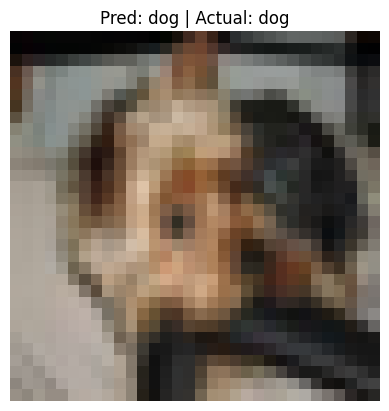

In [11]:
idx = np.random.randint(0, len(x_test))
img = x_test[idx]

input_img = img/255.0
input_img = np.expand_dims(input_img, axis=0)

pred = cnn.predict(input_img)

pred_class = np.argmax(pred[0])
actual = int(y_test[idx][0])

print("Predicted:", class_names[pred_class])
print("Actual:", class_names[actual])

plt.imshow(img)
plt.title(f"Pred: {class_names[pred_class]} | Actual: {class_names[actual]}")
plt.axis('off')
plt.show()